In [1]:
!pip install torch torchvision torchaudio
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid

In [3]:
dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0]

print(data)

Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Done!


In [10]:
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GCN(
    input_dim=dataset.num_node_features,
    hidden_dim=8,
    output_dim=dataset.num_classes
).to(device)

data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)

In [12]:
def train():
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    return loss.item()

In [13]:
def test():
    model.eval()
    out = model(data.x, data.edge_index)

    pred = out.argmax(dim=1)

    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = pred[mask] == data.y[mask]
        acc = int(correct.sum()) / int(mask.sum())
        accs.append(acc)

    return accs

In [17]:
train_losses = []
train_acc_list = []
val_acc_list = []
test_acc_list = []

In [18]:
best_val = 0
best_test = 0
patience = 20
counter = 0

for epoch in range(1, 201):
    loss = train()
    train_acc, val_acc, test_acc = test()

    train_losses.append(loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    test_acc_list.append(test_acc)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc
        counter = 0
    else:
        counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, "
              f"Train: {train_acc:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}")

    if counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest Val Acc: {best_val:.4f}, Corresponding Test Acc: {best_test:.4f}")

Epoch 010, Loss: 0.2863, Train: 1.0000, Val: 0.7560, Test: 0.7840
Epoch 020, Loss: 0.1925, Train: 1.0000, Val: 0.7580, Test: 0.7770

Early stopping at epoch 21

Best Val Acc: 0.7640, Corresponding Test Acc: 0.7790


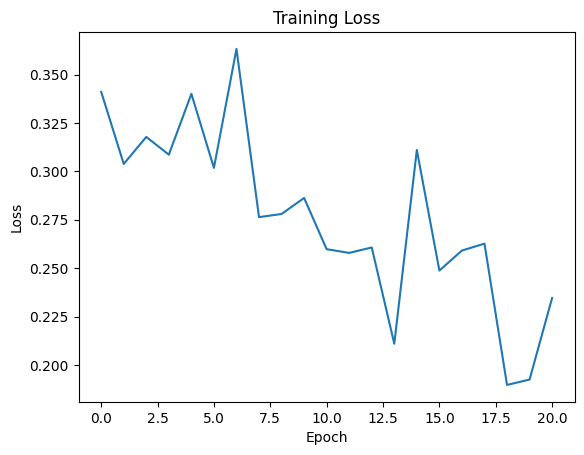

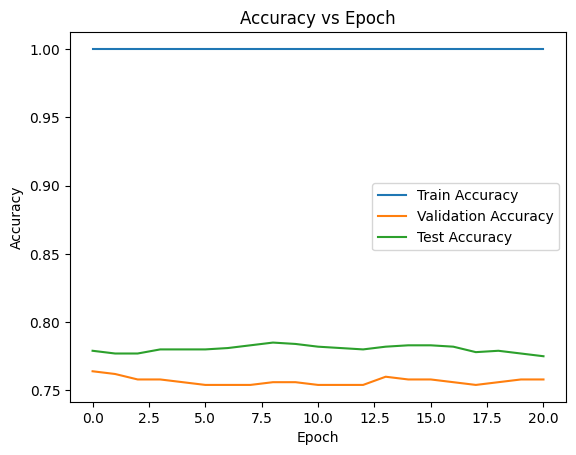

In [19]:
import matplotlib.pyplot as plt

# Loss Graph
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Accuracy Graph
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.plot(test_acc_list, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
out = model(data.x, data.edge_index)
pred = out.argmax(dim=1)

y_true = data.y[data.test_mask].cpu()
y_pred = pred[data.test_mask].cpu()

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.77      0.71       130
           1       0.64      0.87      0.73        91
           2       0.88      0.89      0.88       144
           3       0.93      0.66      0.77       319
           4       0.76      0.83      0.79       149
           5       0.73      0.75      0.74       103
           6       0.67      0.89      0.77        64

    accuracy                           0.78      1000
   macro avg       0.75      0.81      0.77      1000
weighted avg       0.80      0.78      0.78      1000

Confusion Matrix:

[[100   4   3   5   6   3   9]
 [  5  79   3   3   0   0   1]
 [  3  10 128   3   0   0   0]
 [ 22  25   8 211  32  13   8]
 [  8   2   0   5 123  10   1]
 [  9   4   4   0   0  77   9]
 [  4   0   0   1   0   2  57]]


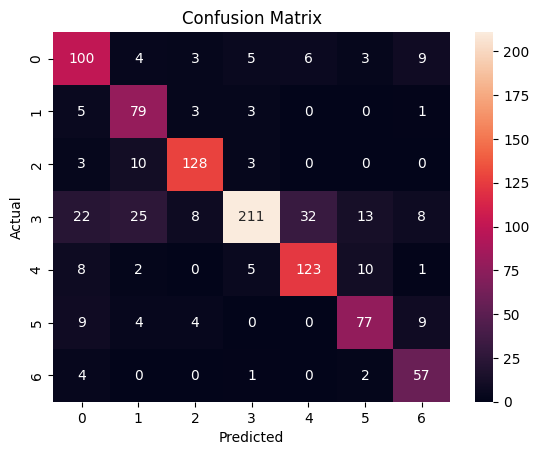

In [21]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()